# Первая лабораторная работа: fusion на датасете PMEmo

## Импорты и константы

In [2]:
import re
import warnings
from pathlib import Path
from pprint import pp

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, silhouette_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from transformers import BertModel, BertTokenizer

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
SR = 16000
RANDOM_STATE = 42

In [4]:
AUDIO_CORPUS_PATH = Path("data/PMEmo2019/chorus")
LYRICS_CORPUS_PATH = Path("data/PMEmo2019/lyrics")
ANNOTATIONS = Path("data/PMEmo2019/genre_annotations/genre_annotations.csv")

In [5]:
annotations_df = pd.read_csv(ANNOTATIONS, sep=",", index_col="musicId")
annotations_df.head()

,genre
musicId,
1,Hip-Hop/Rap
4,Hip-Hop/Rap
5,Hip-Hop/Rap
6,Hip-Hop/Rap
7,Pop


In [6]:
audio_paths = []
text_paths = []
annotations = []

for root, dirs, files in AUDIO_CORPUS_PATH.walk():
    for file in files:
        audio_path = root / file
        try:
            music_id = int(str(Path(file).with_suffix("")))
            annotation = annotations_df.loc[music_id]

            text_path = LYRICS_CORPUS_PATH / Path(file).with_suffix(".lrc")
            if not text_path.exists():
                continue

            audio_paths.append(audio_path)
            text_paths.append(text_path)
            annotations.append(annotation["genre"])
        except KeyError:
            pass

In [7]:
genres = set(annotations)
pp(genres)

{'Country',
 'Dance/Electronic',
 'Hip-Hop/Rap',
 'Pop',
 'R&B/Soul',
 'Rock/Alternative'}


In [8]:
print(f"Кол-во аудиозаписей: {len(audio_paths)}\nКол-во лейблов: {len(annotations)}")

Кол-во аудиозаписей: 556
Кол-во лейблов: 556


In [9]:
def read_lrc(text_path):
    def lrc_preprocess(line):
        line = line.strip()
        line = re.sub(r"\[.+\]", "", line)
        return line

    with open(text_path) as f:
        lrc_list = f.readlines()
    lrc_list = [lrc_preprocess(lrc_string) for lrc_string in lrc_list]
    lrc_list = list(filter(len, lrc_list))

    return lrc_list

In [10]:
def make_audio_windows(audio, len_window_ms=30):
    len_window_samples = int(len_window_ms / 1000 * SR)
    windows = []
    for window in range(0, len(audio), len_window_samples):
        if (window + len_window_samples) <= len(audio):
            windows.append(audio[window : window + len_window_samples])
        else:
            windows.append(audio[window:])
    return windows

## Извлечение признаков

### Собственные аудио векторы

In [11]:
def build_feature_vector(audio, n_mfcc=13):
    rms = librosa.feature.rms(y=audio)

    chroma = librosa.feature.chroma_stft(
        y=audio,
        sr=SR
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SR,
        n_mfcc=n_mfcc
    )

    mfcc_delta = librosa.feature.delta(mfcc)

    contrast = librosa.feature.spectral_contrast(
        y=audio,
        sr=SR
    )

    flatness = librosa.feature.spectral_flatness(
        y=audio
    )

    def pool(feature):
        return np.concatenate([
            np.mean(feature, axis=1),
            np.std(feature, axis=1)
        ])

    vec = np.concatenate([
        pool(rms),
        pool(chroma),
        pool(mfcc),
        pool(mfcc_delta),
        pool(contrast),
        pool(flatness)
    ])

    return torch.tensor(
        vec,
        dtype=torch.float32
    )

In [12]:
audio_feature_vectors = []
for audio_path in tqdm(audio_paths):
    audio, _ = librosa.load(audio_path, sr=SR)
    audio_feature_vectors.append(
        build_feature_vector(audio)
    )

  0%|          | 0/556 [00:00<?, ?it/s]

100%|██████████| 556/556 [03:32<00:00,  2.61it/s] 


In [ ]:
torch.save(audio_feature_vectors, "embeddings/audio_feature_vectors.pt")

### BERT

In [14]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

bert_model = bert_model.to(device) # type: ignore

In [15]:
bert_embeddings = []
for text_path in tqdm(text_paths):
    # -> [[lyrics line], [lyrics line]]
    text = read_lrc(text_path)
    # text = "\n".join(read_lrc(text_path))
    
    inputs = bert_tokenizer(
        text,
        return_tensors="pt",
        padding=True
    )
    inputs = inputs.to(device)

    with torch.inference_mode():
        outputs = bert_model(
            **inputs, 
            output_hidden_states=True
        )

    features = outputs.last_hidden_state
    embedding = features.mean(dim=0).mean(dim=0).to("cpu")    

    bert_embeddings.append(embedding)

100%|██████████| 556/556 [01:44<00:00,  5.32it/s]


In [16]:
bert_embeddings[0].shape

torch.Size([768])

In [ ]:
torch.save(bert_embeddings, "embeddings/bert_embeddings.pt")

## EDA

### Аудио

In [ ]:
colors = {
    "Country": "red",
    "Dance/Electronic": "blue",
    "Hip-Hop/Rap": "orange",
    "Pop": "purple",
    "R&B/Soul": "green",
    "Rock/Alternative": "black",
}

In [25]:
audio_embeddings = torch.load("embeddings/audio_feature_vectors.pt")

In [26]:
pca = PCA(n_components=2)
audio_emb_PCA = pca.fit_transform(audio_embeddings)
audio_emb_PCA_X = [emb[0] for emb in audio_emb_PCA]
audio_emb_PCA_Y = [emb[1] for emb in audio_emb_PCA]

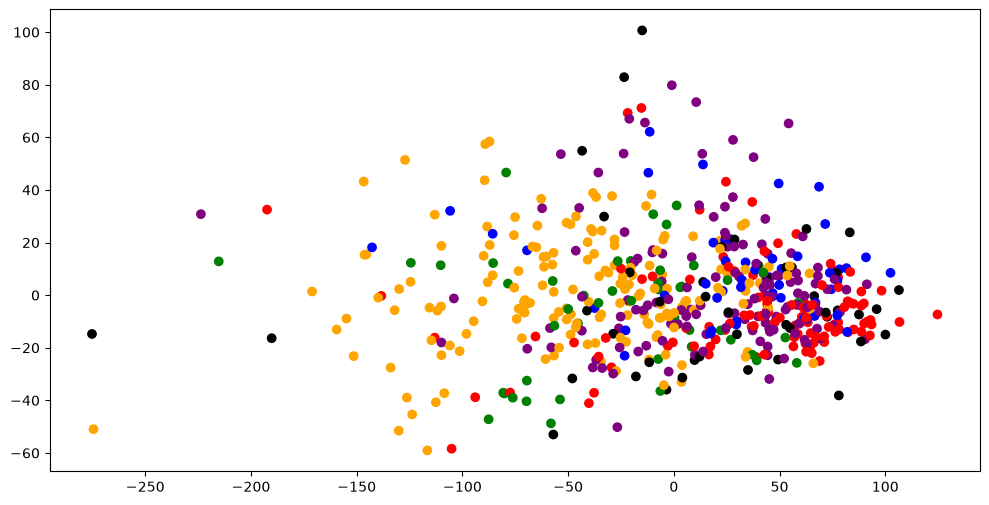

In [27]:
plt.figure(figsize=(12, 6))
plt.scatter(
    audio_emb_PCA_X, 
    audio_emb_PCA_Y,
    c=[colors[genre] for genre in annotations]
)
plt.show()

In [28]:
silhouette_val = silhouette_score(audio_embeddings, annotations)
print("Silhouette:", silhouette_val)

Silhouette: -0.05607191100716591


In [29]:
clusters = KMeans(
    n_clusters=len(genres),
    random_state=RANDOM_STATE,
).fit_predict(audio_embeddings)

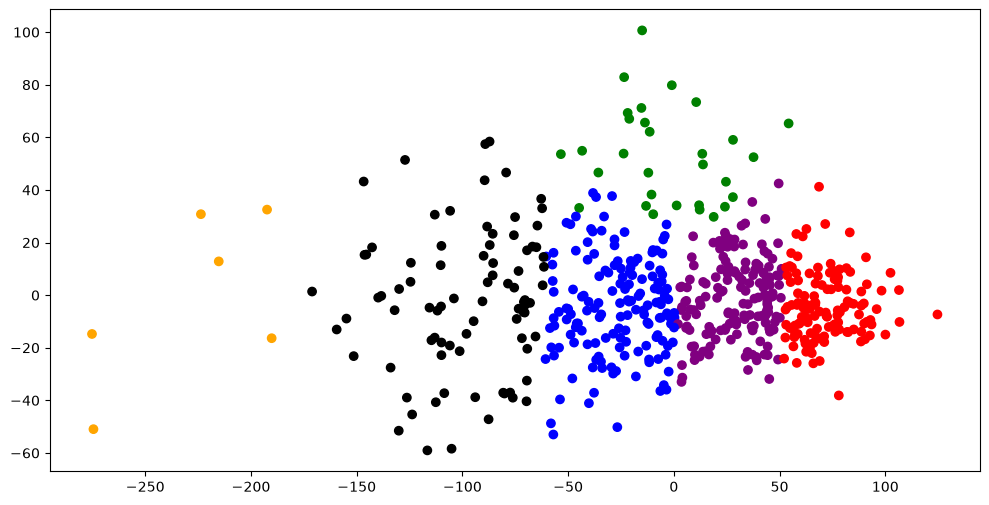

In [31]:
plt.figure(figsize=(12, 6))
plt.scatter(
    audio_emb_PCA_X, 
    audio_emb_PCA_Y,
    c=[list(colors.values())[cluster] for cluster in clusters]
)
plt.show()

[ ] Сделать кластеры

[ ] Посчитать среднее расстояние между представителями одного класса и представителями разного

### Текст

In [ ]:
text_embeddings = torch.load("embeddings/bert_embeddings.pt")

In [23]:
colors = {
    "Country": "red",
    "Dance/Electronic": "blue",
    "Hip-Hop/Rap": "orange",
    "Pop": "purple",
    "R&B/Soul": "green",
    "Rock/Alternative": "black",
}

In [24]:
pca = PCA(n_components=2)
text_emb_PCA = pca.fit_transform(text_embeddings)
text_emb_PCA_X = [emb[0] for emb in text_emb_PCA]
text_emb_PCA_Y = [emb[1] for emb in text_emb_PCA]

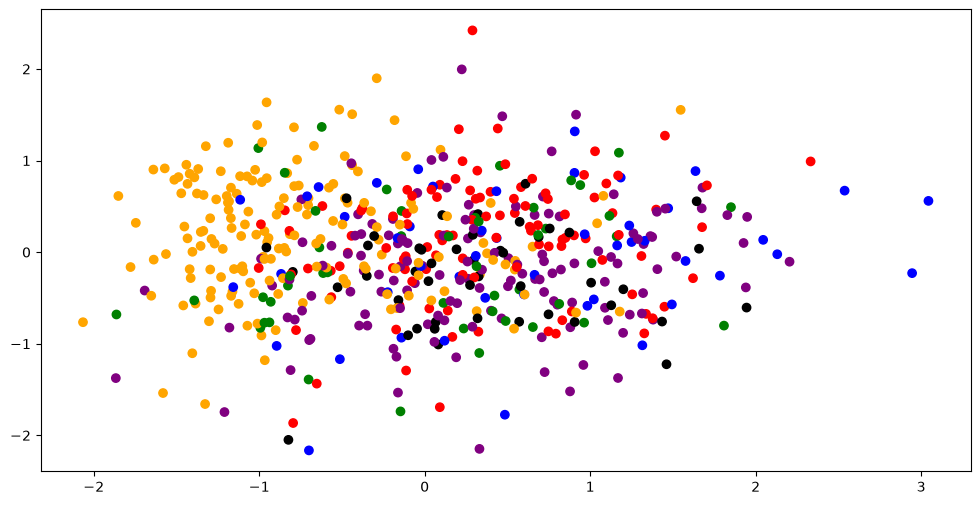

In [25]:
plt.figure(figsize=(12, 6))
plt.scatter(
    text_emb_PCA_X, 
    text_emb_PCA_Y,
    c=[colors[genre] for genre in annotations]
)
plt.show()

In [ ]:
silhouette_val = silhouette_score(text_embeddings, annotations)
print("Silhouette:", silhouette_val)

Silhouette: 0.00038709950260818


## Классификаторы по отдельности

### Аудио

In [ ]:
audio_embeddings = torch.load("embeddings/audio_feature_vectors.pt")

In [ ]:
audio_vectors_train, audio_vectors_test, \
    annotations_train, annotations_test = train_test_split(
        audio_embeddings,
        annotations, 
        test_size=0.2, 
        random_state=RANDOM_STATE
)

In [ ]:
rfc = RandomForestClassifier(
    random_state=RANDOM_STATE
)
params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(
    rfc,
    params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="f1_macro",
)

In [29]:
grid.fit(audio_vectors_train, annotations_train)
best_estimator = grid.best_estimator_

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [30]:
rfc_preds = best_estimator.predict(audio_vectors_test)
print(classification_report(annotations_test, rfc_preds))

                  precision    recall  f1-score   support

         Country       0.55      0.84      0.67        19
Dance/Electronic       0.33      0.07      0.11        15
     Hip-Hop/Rap       0.79      0.91      0.85        34
             Pop       0.39      0.44      0.42        25
        R&B/Soul       0.25      0.08      0.12        12
Rock/Alternative       0.11      0.14      0.12         7

        accuracy                           0.54       112
       macro avg       0.41      0.41      0.38       112
    weighted avg       0.50      0.54      0.50       112



In [ ]:
joblib.dump(best_estimator, "models/audio_classifier.joblib")

['audio_classifier.joblib']

### Текст

In [ ]:
text_embeddings = torch.load("embeddings/bert_embeddings.pt")

In [33]:
text_embeddings_train, text_embeddings_test, \
    annotations_train, annotations_test = train_test_split(
        text_embeddings,
        annotations, 
        test_size=0.2, 
        random_state=RANDOM_STATE
)

In [34]:
text_embeddings_train[0].shape, annotations_train[0]

(torch.Size([768]), 'Country')

In [35]:
rfc = RandomForestClassifier(
    random_state=RANDOM_STATE
)
params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(
    rfc,
    params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="f1_macro",
)

In [36]:
grid.fit(text_embeddings_train, annotations_train)
best_estimator = grid.best_estimator_

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [37]:
rfc_preds = best_estimator.predict(text_embeddings_test)
print(classification_report(annotations_test, rfc_preds))

                  precision    recall  f1-score   support

         Country       0.45      0.68      0.54        19
Dance/Electronic       0.33      0.13      0.19        15
     Hip-Hop/Rap       0.81      0.85      0.83        34
             Pop       0.39      0.44      0.42        25
        R&B/Soul       0.00      0.00      0.00        12
Rock/Alternative       0.22      0.29      0.25         7

        accuracy                           0.51       112
       macro avg       0.37      0.40      0.37       112
    weighted avg       0.47      0.51      0.48       112



In [ ]:
joblib.dump(best_estimator, "models/text_classifier.joblib")

['text_classifier.joblib']

## Fusion

### Early Fusion

In [59]:
audio_embeddings = torch.load("embeddings/audio_feature_vectors.pt")
text_embeddings = torch.load("embeddings/bert_embeddings.pt")

early_fused_embs = []
for audio_emb, text_emb in zip(audio_embeddings, text_embeddings):
    early_fused_embs.append(
        torch.cat((audio_emb, text_emb))
    )

In [60]:
len(early_fused_embs), len(annotations)

(556, 556)

In [61]:
early_fused_embs_train, early_fused_embs_test, \
    annotations_train, annotations_test = train_test_split(
        early_fused_embs,
        annotations
    )

In [62]:
scaler = StandardScaler()
early_fused_embs_train = scaler.fit_transform(early_fused_embs_train)
early_fused_embs_test = scaler.transform(early_fused_embs_test)

In [63]:
rfc = RandomForestClassifier(
    random_state=RANDOM_STATE
)
params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(
    rfc,
    params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="f1_macro",
)

In [64]:
grid.fit(early_fused_embs_train, annotations_train)
best_estimator = grid.best_estimator_

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [65]:
rfc_preds = best_estimator.predict(early_fused_embs_test)
print(classification_report(annotations_test, rfc_preds))

                  precision    recall  f1-score   support

         Country       0.65      0.62      0.63        39
Dance/Electronic       0.17      0.11      0.13         9
     Hip-Hop/Rap       0.80      0.88      0.84        41
             Pop       0.42      0.56      0.48        27
        R&B/Soul       0.20      0.08      0.12        12
Rock/Alternative       0.20      0.18      0.19        11

        accuracy                           0.57       139
       macro avg       0.41      0.40      0.40       139
    weighted avg       0.54      0.57      0.55       139



### Intermideate Fusion

### Late Fusion

In [ ]:
audio_classifier = joblib.load("models/audio_classifier.joblib")
text_classifier = joblib.load("models/text_classifier.joblib")

In [47]:
early_fused_embs = []
for audio_emb, text_emb in zip(audio_embeddings, text_embeddings):
    early_fused_embs.append(
        torch.cat((audio_emb, text_emb))
    )

In [48]:
len(early_fused_embs), len(annotations)

(556, 556)

In [49]:
early_fused_embs_train, early_fused_embs_test, \
    annotations_train, annotations_test = train_test_split(
        early_fused_embs,
        annotations
)

In [50]:
voting_classifier = VotingClassifier(
    estimators=[
        ("audio_clf", audio_classifier),
        ("text_clf", text_classifier),
    ],
    voting='soft',
)
voting_classifier.fit(
    early_fused_embs_train, 
    annotations_train
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('audio_clf', ...), ('text_clf', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[<U16](6,)","['Country','Dance/Electronic','Hip-Hop/Rap','Pop','R&B/Soul', 'Rock/Alternative']"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC...ndom_state=42), RandomForestC...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,862


In [51]:
rfc_preds = voting_classifier.predict(early_fused_embs_test)
print(classification_report(annotations_test, rfc_preds))

                  precision    recall  f1-score   support

         Country       0.52      0.68      0.59        25
Dance/Electronic       0.20      0.10      0.13        10
     Hip-Hop/Rap       0.76      0.91      0.83        46
             Pop       0.52      0.40      0.45        40
        R&B/Soul       0.00      0.00      0.00         8
Rock/Alternative       0.14      0.10      0.12        10

        accuracy                           0.55       139
       macro avg       0.36      0.37      0.35       139
    weighted avg       0.52      0.55      0.53       139

